# Pareto Analysis

**Module 2: Data Visualization** | Lean Six Sigma Data Analytics

---

## The 80/20 Principle

> **80% of all problems can be attributed to 20% of the causes.**

Also known as:
- The Pareto Principle
- The rule of the **vital few** and the **trivial many**

This rule of thumb helps prioritize problem-solving efforts by focusing on the causes that matter most.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')


Data loaded successfully!


---

## Example: Cookie Factory Production Stops

**Context:** You work in a factory producing cookies. Sometimes the production line stops due to problems. You've recorded data on these stops.

**Objective:** Reduce time lost due to production stops by identifying the most impactful causes.

In [2]:
# Load Pareto data
pareto_data = pd.read_excel(xlsx, sheet_name='Pareto', skiprows=4)
pareto_data.columns = ['Stop_ID', 'Duration', 'Cause']
pareto_data = pareto_data.dropna(subset=['Cause'])
pareto_data['Duration'] = pd.to_numeric(pareto_data['Duration'], errors='coerce')

print(f'Dataset: {pareto_data.shape[0]} production stops')
print(f'Unique causes: {pareto_data["Cause"].nunique()}')
print(f'Valid durations: {pareto_data["Duration"].notna().sum()}')
pareto_data.head(10)

Dataset: 92 production stops
Unique causes: 17
Valid durations: 87


,Stop_ID,Duration,Cause
0,NaN,NaN,Cause of the stop
2,Stops,NaN,Cause
3,1,30.0,Deviation in dimensions
4,2,45.0,Break
5,3,NaN,Deviation in dimensions
6,4,40.0,Problem with dough
7,5,55.0,Break
8,6,65.0,Deviation in dimensions
9,7,35.0,Maintenance
10,8,20.0,Problems with knife


---

## What is a Pareto Chart?

A Pareto chart combines a bar chart with a cumulative line:

- **Bars:** Categories sorted by frequency (highest to lowest)
- **Cumulative line:** Running total as percentage
- **80% threshold:** Identifies the "vital few" causes

### Two Types

| Type | What It Shows | Use When |
|------|--------------|----------|
| **Count-based** | How often each cause occurs | Frequency matters most |
| **Weighted** | Impact weighted by duration/cost | Impact matters more than frequency |

In [3]:
# Pareto Chart Function - equivalent to Minitab: Stat > Quality Tools > Pareto Chart
def pareto_chart(data, category_col, weight_col=None, title='Pareto Chart'):
    """
    Create a Pareto chart.
    
    Parameters:
    - category_col: Column with categories to count
    - weight_col: Optional column to weight by (e.g., duration, cost)
    """
    if weight_col:
        counts = data.groupby(category_col)[weight_col].sum().sort_values(ascending=False)
        ylabel = f'Total {weight_col}'
    else:
        counts = data[category_col].value_counts()
        ylabel = 'Count'
    
    cumulative = counts.cumsum() / counts.sum() * 100
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    
    # Bars
    ax1.bar(range(len(counts)), counts.values, color=ms.HIST_FILL, alpha=0.7, edgecolor=ms.HIST_EDGE)
    ax1.set_xticks(range(len(counts)))
    ax1.set_xticklabels(counts.index, rotation=45, ha='right')
    ax1.set_ylabel(ylabel)
    ax1.set_xlabel('Cause')
    
    # Value labels on bars
    for i, val in enumerate(counts.values):
        ax1.text(i, val + max(counts.values)*0.02, f'{val:.0f}', ha='center', fontsize=9)
    
    # Cumulative line
    ax2.plot(range(len(counts)), cumulative.values, color=ms.RED, marker='o', linestyle='-', markersize=6)
    ax2.axhline(80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
    ax2.set_ylabel('Cumulative %')
    ax2.set_ylim(0, 105)
    
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    return counts, cumulative

---

## Count-Based Pareto Chart

**Question:** Which causes occur most frequently?

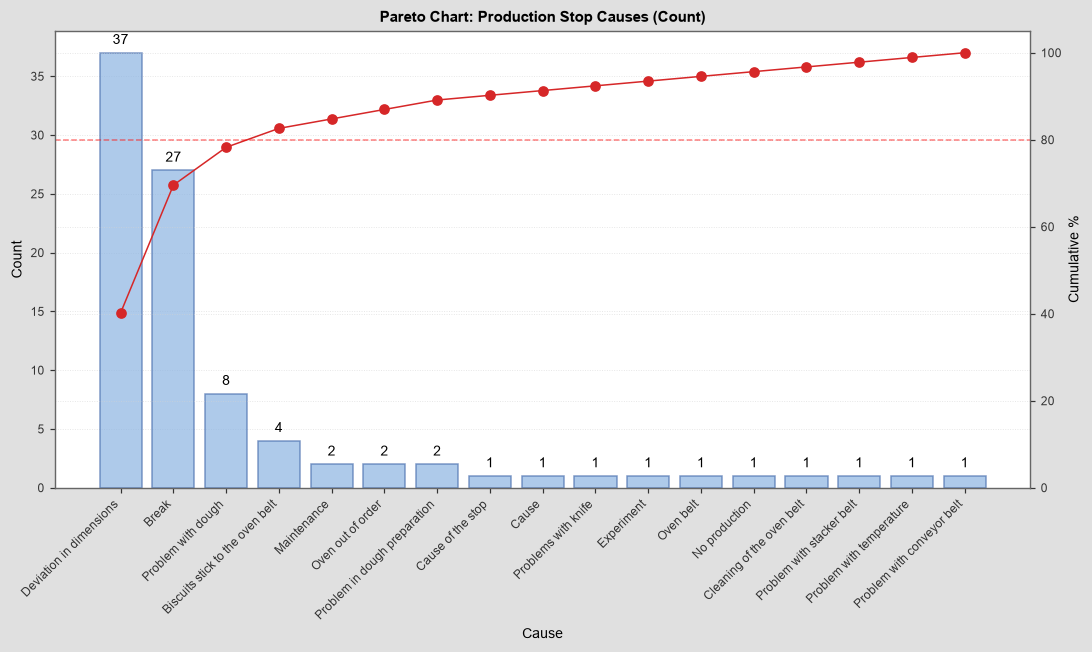

Count-Based Analysis
Total production stops: 92

Vital few causes (contributing to ~80% of stops):
  - Deviation in dimensions: 37 stops (40.2% cumulative)
  - Break: 27 stops (69.6% cumulative)
  - Problem with dough: 8 stops (78.3% cumulative)


In [4]:
# Count-based Pareto
counts, cumulative = pareto_chart(pareto_data, 'Cause', 
                                   title='Pareto Chart: Production Stop Causes (Count)')

print('Count-Based Analysis')
print('=' * 50)
print(f'Total production stops: {counts.sum()}')
print()

# Identify vital few (causes contributing to ~80%)
vital_few = cumulative[cumulative <= 80]
print('Vital few causes (contributing to ~80% of stops):')
for cause, pct in vital_few.items():
    print(f'  - {cause}: {counts[cause]} stops ({pct:.1f}% cumulative)')

---

## Duration-Weighted Pareto Chart

**Question:** Which causes consume the most time?

A problem that occurs frequently but is quickly resolved may be less important than a rare problem that takes hours to fix.

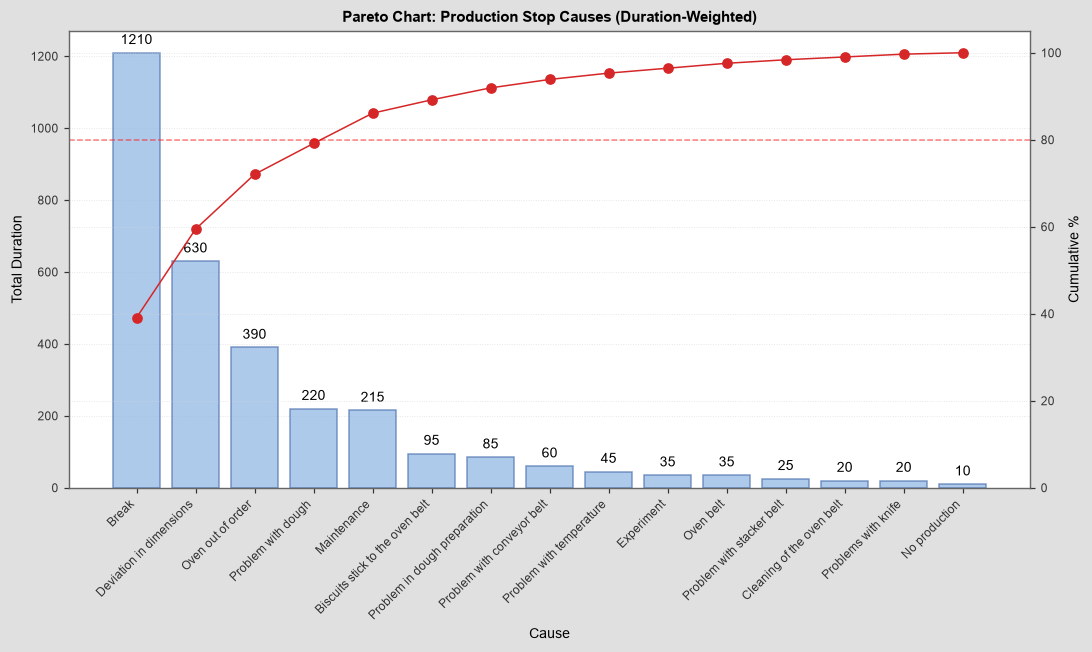

Duration-Weighted Analysis
Total duration lost: 3095 minutes

Vital few causes (contributing to ~80% of time lost):
  - Break: 1210 min (39.1% cumulative)
  - Deviation in dimensions: 630 min (59.4% cumulative)
  - Oven out of order: 390 min (72.0% cumulative)
  - Problem with dough: 220 min (79.2% cumulative)


In [5]:
# Duration-weighted Pareto
duration_counts, duration_cumulative = pareto_chart(
    pareto_data.dropna(subset=['Duration']),
    'Cause', 
    weight_col='Duration',
    title='Pareto Chart: Production Stop Causes (Duration-Weighted)'
)

print('Duration-Weighted Analysis')
print('=' * 50)
print(f'Total duration lost: {duration_counts.sum():.0f} minutes')
print()

vital_few_duration = duration_cumulative[duration_cumulative <= 80]
print('Vital few causes (contributing to ~80% of time lost):')
for cause, pct in vital_few_duration.items():
    print(f'  - {cause}: {duration_counts[cause]:.0f} min ({pct:.1f}% cumulative)')

---

## Comparing Count vs Duration

The most frequent problem isn't always the most impactful!

In [6]:
# Compare rankings
print('Count vs Duration Comparison')
print('=' * 60)

comparison = pd.DataFrame({
    'Count Rank': range(1, len(counts) + 1),
    'Count': counts.values,
    'Duration Rank': [list(duration_counts.index).index(c) + 1 
                     if c in duration_counts.index else '-' 
                     for c in counts.index],
    'Duration (min)': [duration_counts.get(c, 0) for c in counts.index]
}, index=counts.index)

display(comparison)

print()
print('Key Insight:')
print('  - Most FREQUENT problem may not be most TIME-CONSUMING')
print('  - Use weighted Pareto when impact (time/cost) matters more than frequency')
print('  - Focus on the VITAL FEW, not the trivial many')

Count vs Duration Comparison


,Count Rank,Count,Duration Rank,Duration (min)
Cause,,,,
Deviation in dimensions,1,37,2,630.0
Break,2,27,1,1209.6
Problem with dough,3,8,4,220.0
Biscuits stick to the oven belt,4,4,6,95.0
Maintenance,5,2,5,215.0
Oven out of order,6,2,3,390.0
Problem in dough preparation,7,2,7,85.0
Cause of the stop,8,1,-,0.0
Cause,9,1,-,0.0



Key Insight:
  - Most FREQUENT problem may not be most TIME-CONSUMING
  - Use weighted Pareto when impact (time/cost) matters more than frequency
  - Focus on the VITAL FEW, not the trivial many


---

## The Vital Few vs Trivial Many

| Category | Description | Action |
|----------|-------------|--------|
| **Vital Few** | Small number of causes creating most impact | Focus here first |
| **Trivial Many** | Many causes with minor individual impact | Address later |

**Note:** It won't always be exactly 80/20. Could be 70/10 or 90/30. The principle: a small number of causes drive most of the results.

---

## Key Takeaways

- **Pareto chart:** Bars sorted by frequency + cumulative line
- **80/20 principle:** Vital few causes create most problems
- **Two types:** Count-based (frequency) and weighted (duration, cost, etc.)
- **Key insight:** Most frequent ≠ most impactful; use weighted analysis
- **Action:** Focus on the vital few, not the trivial many